# COGS 108 - EDA Checkpoint

## Authors
- Devam Parekh: Data Cleaning, Wrangling, Tidying
- Thomas Cung: Ethics and Data Cleaning, Wrangling, Tidying
- Russell Ng: Dataset #2 Overview, Hypothesis, and Research Question
- Joshua Narciso: Dataset #1 Overview and Background and Prior Work
- Jennifer Nguyen: Dataset #1 and #2 Descriptions, Ethics, Team Expectations, and Project Timeline

# Research Question

What browsing behaviors best predict whether a user completes a purchase or abandons their cart? In order to answer this question, we will be looking at whether or not the consumer purchases the product or not during their session (purchase = 1, no purchase = 0). In order to measure this, possible variables to consider include product-related page views, page values, bounce rate, exit rate, total session duration, return visits, traffic source, time period (weekend/holiday), cart-related interactions (add/removing items from cart) etc… This project is going to be a prediction task that can model the probability someone is willing to purchase an item based on their actions. Model performance could be evaluated with accuracy, precision, F1 score, etc.

## Background and Prior Work

Online shopping has become a central part of everyday life, with billions of visits to e‑commerce sites generating trillions of dollars in global sales each year. As more people start to browse and buy online, each visit leaves a record of clicks, page views, and the duration of time spent on screens to curate behavioral data. Instead of only looking at final sales numbers, companies now rely on web analytics and machine learning to understand what people actually do on their sites. This shift from aggregate sales metrics to behavioral analysis makes it possible to model which types of browsing sessions are most likely to end in a purchase versus an abandoned cart. In this project, we will use a dataset to model which patterns of on site browsing behavior are most predictive of whether a session results in a completed purchase or an abandoned cart.

Some prior work to highlight related to this topic include Gkikas and Theodoridis (2024), who take this idea and apply it to a real fashion ecommerce site using Google Analytics data. They look at a small set of familiar metrics such as event count, sessions, purchase revenue, transactions, and bounce rate, then use models like decision trees, Naive Bayes, and k‑nearest neighbors to classify users into different engagement levels. In their results, decision trees stand out because they are both accurate and easy to interpret, which is useful for marketers who need simple rules rather than black‑box predictions.

Another work that could help contextualize our project would be from The Online Shoppers Purchasing Intention dataset, introduced by Sakar et al., because of how it already summarizes 12,330 user sessions with features that describe page categories, time spent, and analytics metrics like bounce rate, exit rate, page value, and a binary Revenue label for whether the user bought something or not. In their paper, Sakar et al. frame this as a binary classification problem and experiment with multilayer perceptrons and neural networks to predict purchasing intention in real time. 

It is also important to note that behavioral logs only show what users are doing on the surface. They do not directly reveal why they make certain choices. Research on online purchase intention points out that factors such as perceived risk, perceived reputation, and trust in the website also shape whether someone feels comfortable buying online, as shown in recent work by Ikhlash and Linda on how risk perception and online trust influence e‑commerce purchase intention. It is possible that a user may view many product pages and spend a long time on the site but still decide not to buy because they may feel like they do not have the funds currently to buy.

<a name="fn1">1.</a> Gkikas, D. C., & Theodoridis, P. K. (2024). Predicting online shopping behavior: Using machine learning and Google Analytics to classify user engagement. Applied Sciences, 14(23), 11403. https://doi.org/10.3390/app142311403 <a href="#fnref1">^</a>

<a name="fn2">2.</a> Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real‑time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks. Neural Computing and Applications, 31(10), 6893–6908. https://link.springer.com/article/10.1007/s00521-018-3523-0 <a href="#fnref2">^</a>

<a name="fn3">3.</a> Ikhlash, M., & Linda, K. R. (2024). The effect of risk perception and online trust on purchase intention in e‑commerce. International Review of Management and Marketing, 14(6), 109–118. https://www.econjournals.com/index.php/irmm/article/download/17111/8280/39919 <a href="#fnref3">^</a>

# Hypothesis


We hypothesize a strong positive correlation between Page Values and Informational Duration to be significant predictors of a purchase, while Bounce Rates to have a strong negative correlation with not purchasing an item. Engagement will be measured using “Time on Site” and “Product Related”. This prediction is based on the inductive reasoning that users who spend more time on a page signals that they show more interest in purchasing the product. This aligns with our research of how web analytics can differentiate between a purposeful browsing session or a non-purchase.


## Data

### Data overview

- Dataset Name: Online Shop pers Purchasing Intention Dataset
- Link to the dataset: https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset
- Number of observations: 12,330
- Number of variables: 18
- Description of the variables most relevant to this project: The Online Shoppers Purchasing Intention dataset is a strong fit for our project because it is built around individual browsing sessions and includes a binary Revenue variable that matches our outcome of whether a session ends in a purchase or not. It provides detailed session level measures of engagement, including counts and total duration for product related, administrative, and informational pages, along with BounceRate, ExitRate, and PageValue, which align closely with our interest in page views, time spent, and abandonment behavior. Context variables such as SpecialDay, Month, Weekend, VisitorType, and TrafficType also support our focus on return visits and temporal factors like weekends or holidays, allowing us to model how different patterns of browsing behavior relate to purchase intention.
- Descriptions of any shortcomings this dataset has with repsect to the project: However, this dataset also has important limitations relative to our ideal data. It only contains aggregated session level features, so we do not observe fine grained click sequences or explicit cart level events like adding or removing items, which makes it harder to distinguish true cart abandonment from general non purchase browsing. All observations come from a single e-commerce site over one year and there is no demographic or persistent user identifier information beyond a VisitorType flag, which limits our ability to study differences across user groups and reduces how well our models might generalize to other sites or populations. In addition, the time information is fairly coarse (month, weekend, and proximity to a special day rather than exact timestamps), and the Revenue label is likely imbalanced, so we will need to be careful with evaluation metrics and be transparent about these constraints when interpreting our results.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [4]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv', 'filename': 'online_shoppers_intention.csv' }
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  33%|███▎      | 1/3 [00:00<00:01,  1.53it/s]

Successfully downloaded: airline-safety.csv


Overall Download Progress:  67%|██████▋   | 2/3 [00:01<00:00,  1.43it/s]

Successfully downloaded: bad-drivers.csv


Overall Download Progress: 100%|██████████| 3/3 [00:02<00:00,  1.21it/s]


Successfully downloaded: online_shoppers_intention.csv


### Online Shoppers Purchasing Intention Dataset

The Online Shoppers Purchasing Intention Dataset captures user behavior on an e-commerce website to predict whether a session results in a purchase. Key numeric metrics include the number of pages visited in different categories: "Administrative", "Informational", and "Product Related", which count how many pages a user browsed in each category, with higher numbers generally indicating greater engagement. Additionally, there are corresponding duration metrics such as "Administrative Duration", "Informational Duration", and "Product Related Duration" that measure the total time spent on those pages in seconds. The longer durations may suggest either interest or difficulty navigating. "Bounce Rate" and "Exit Rate" are fractional values representing the likelihood of leaving pages quickly or ending the session on a page, with higher values typically indicating less engagement. "PageValues" estimates the monetary contribution of pages to revenue, where higher values suggest pages visited by users more likely to purchase. "SpecialDay" measures how close the session occurred to a holiday or special event on a scale from 0 to 1, with values near 1 signifying major shopping days. 

Categorical features include "Month" (month of the session), "OperatingSystems", "Browser", "Region", and "TrafficType" (all int-coded), as well as "VistorType" (new or returning) and "Weekend" (whether the session occurred on a weekend). The target variable, "Revenue", is a boolean indicating whether the session ended in a purchase.

This dataset only includes visitors to a specific e-commerce site, so findings may not generalize to all online shoppers. Sessions likely overrepresent engaged users, while casual visitors may leave without any meaningful interactions. Duration metrics may overestimate attention if users leave the site open when distracted. Additionally, since only a portion of sessions result in purchases, the dataset may be imbalanced, which is important to account for in predictive modeling.

In [5]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
df = pd.read_csv('data/00-raw/online_shoppers_intention.csv')
# The data is already tidy: each variable has its own column, each observation is a row
# No unique identifier exists — we create one
df.insert(0, 'Session_ID', np.arange(len(df)))

# Check for missing data — none found
assert df.isnull().sum().sum() == 0, "Unexpected missing values found"

# Fix Month column: 'June' is inconsistent with 3-letter abbreviations for all other months
df['Month'] = df['Month'].replace('June', 'Jun')

# Convert Month to an ordered categorical for correct chronological sorting/analysis
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Rename VisitorType value for consistency (no spaces/underscores mix)
# Values: 'Returning_Visitor', 'New_Visitor', 'Other' — already consistent, no change needed
# BounceRates and ExitRates are proportions — confirm they stay in [0, 1]
assert df['BounceRates'].between(0, 1).all(), "BounceRates out of range"
assert df['ExitRates'].between(0, 1).all(), "ExitRates out of range"

# SpecialDay is in [0, 1] — confirm
assert df['SpecialDay'].between(0, 1).all(), "SpecialDay out of range"

# Descriptive summary
print(f"Dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNumerical summary:\n{df.describe()}")
print(f"\nMonth distribution:\n{df['Month'].value_counts().sort_index()}")
print(f"\nVisitorType distribution:\n{df['VisitorType'].value_counts()}")
print(f"\nRevenue (purchase made):\n{df['Revenue'].value_counts()}")
df.to_csv('data/02-processed/online_shoppers_intention_cleaned.csv', index=False)
print("\nCleaned dataset saved.")

Dataset shape: (12330, 19)

Missing values:
Session_ID                 0
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Data types:
Session_ID                    int64
Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay         

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

Purchase Rate: 15.47%
         Administrative  Administrative_Duration  Informational  \
Revenue                                                           
False          2.117732                73.740111       0.451833   
True           3.393606               119.483244       0.786164   

         Informational_Duration  ProductRelated  ProductRelated_Duration  \
Revenue                                                                    
False                 30.236237       28.714642              1069.987809   
True                  57.611427       48.210168              1876.209615   

         BounceRates  ExitRates  PageValues  
Revenue                                      
False       0.025317   0.047378    1.975998  
True        0.005117   0.019555   27.264518  

When Revenue is True, there is a significantly higher amount of time spent on each page, potentially backing our claim.


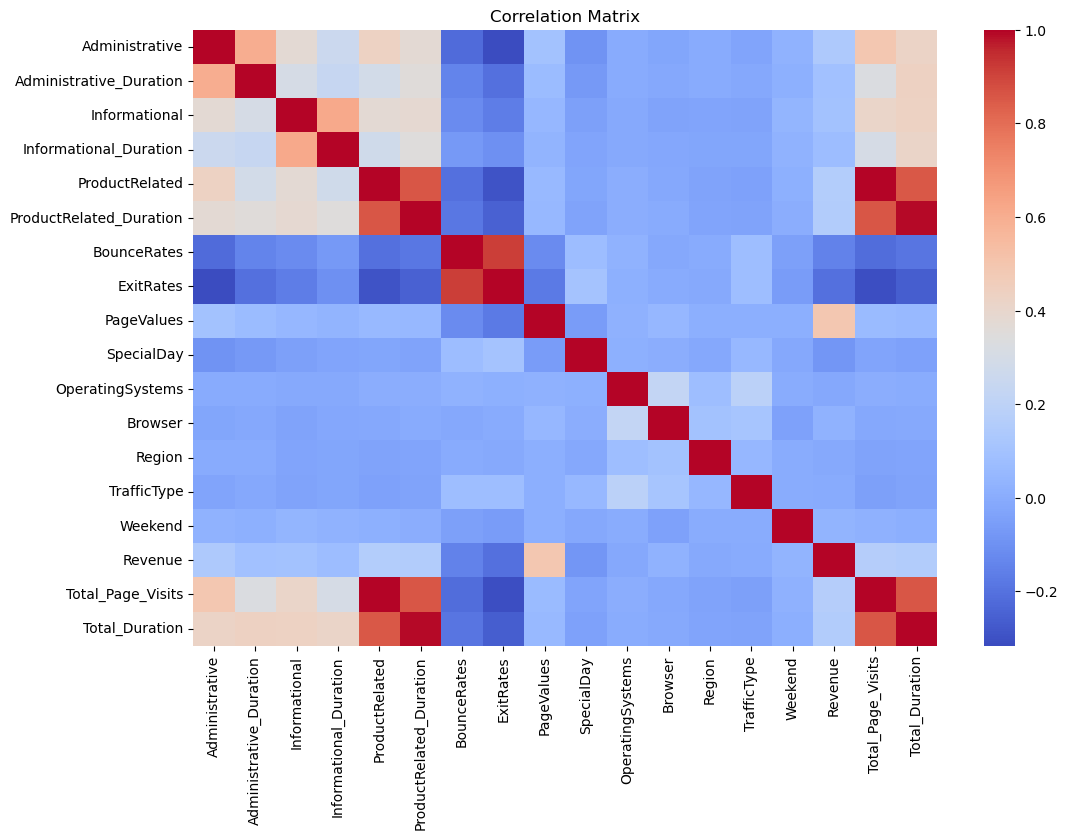


[Correlation Matrix]
- PageValues has the strongest positive correlation with Revenue (r ≈ 0.49),
  making it the single best numeric predictor of a purchase.
- ExitRates shows the strongest negative correlation (r ≈ -0.21),
  followed by BounceRates (r ≈ -0.15).
- BounceRates and ExitRates are highly correlated with each other — they carry
  overlapping information and may need careful treatment during feature selection
  to avoid multicollinearity.



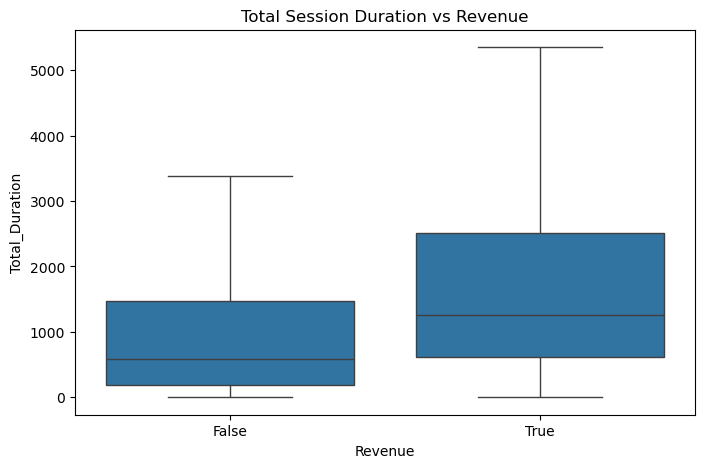

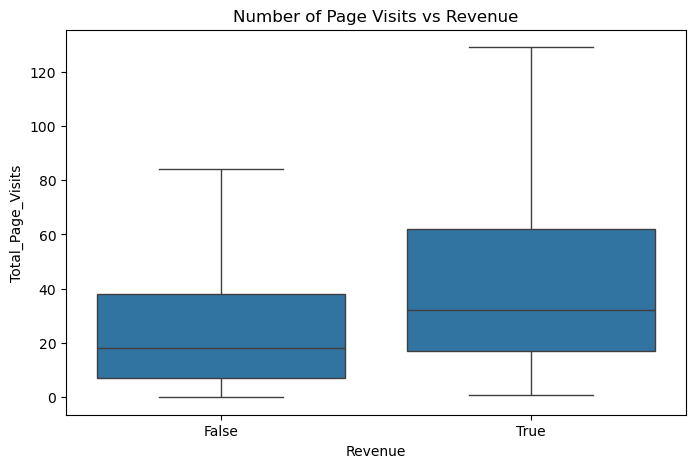


[Total Session Duration and Number of Page Visits vs Revenue]
- Purchasing sessions have a noticeably higher median total duration than
  non-purchasing sessions.
- The wider IQR for purchasers suggests buyers vary more in how long they browse,
  but they consistently spend more time overall.
- This supports the core hypothesis: higher engagement (time on site) correlates
  with a greater likelihood of purchase.



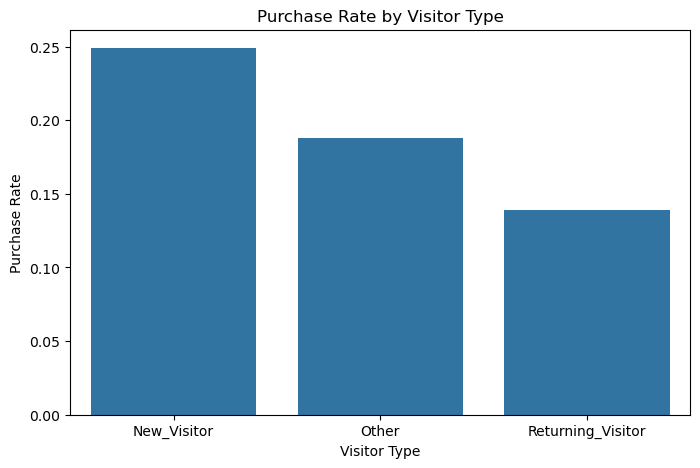


[Purchase Rate by Visitor Type]
- New Visitors convert at roughly 25% — nearly double the rate of
  Returning Visitors (~14%).
- This directly challenges the hypothesis that returning visitors are more
  likely to purchase.
- One explanation: new visitors may arrive with stronger purchase intent
  (e.g. from a targeted ad or referral), while returning visitors are more
  likely browsing casually or researching across multiple sessions.



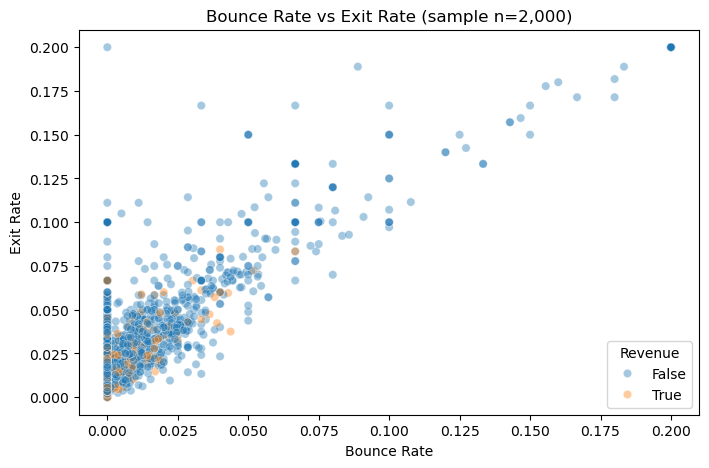


[Bounce Rate vs Exit Rate]
- Sessions ending in a purchase cluster in the lower-left corner —
  low bounce and low exit rates.
- Non-purchasing sessions are far more spread out, with many showing
  high values on both axes.
- Users who leave pages quickly or exit early are significantly less likely to buy.
- The two variables move together, reinforcing that they both reflect the same
  underlying behavior: disengagement.



In [9]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)

df = pd.read_csv('data/02-processed/online_shoppers_intention_cleaned.csv')

# ── Derived features ──────────────────────────────────────────────────────────
df['Total_Page_Visits'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)
df['Total_Duration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

# =============================================================================
# SECTION 1 — Purchase Rate Overview
# =============================================================================
purchase_rate = df['Revenue'].mean()
print(f"Purchase Rate: {purchase_rate:.2%}")

engagement_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues'
]
print(df.groupby('Revenue')[engagement_cols].mean())
print("\nWhen Revenue is True, there is a significantly higher amount of time spent on each page, potentially backing our claim.")

# =============================================================================
# SECTION 2 — Correlation Heatmap
# =============================================================================
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns='Session_ID').corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

print("""
[Correlation Matrix]
- PageValues has the strongest positive correlation with Revenue (r ≈ 0.49),
  making it the single best numeric predictor of a purchase.
- ExitRates shows the strongest negative correlation (r ≈ -0.21),
  followed by BounceRates (r ≈ -0.15).
- BounceRates and ExitRates are highly correlated with each other — they carry
  overlapping information and may need careful treatment during feature selection
  to avoid multicollinearity.
""")

# =============================================================================
# SECTION 3 — Total Session Duration vs Revenue
# =============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='Revenue', y='Total_Duration', data=df, showfliers=False)
plt.title('Total Session Duration vs Revenue')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Revenue', y='Total_Page_Visits', data=df, showfliers=False)
plt.title("Number of Page Visits vs Revenue")
plt.show()

print("""
[Total Session Duration and Number of Page Visits vs Revenue]
- Purchasing sessions have a noticeably higher median total duration than
  non-purchasing sessions.
- The wider IQR for purchasers suggests buyers vary more in how long they browse,
  but they consistently spend more time overall.
- This supports the core hypothesis: higher engagement (time on site) correlates
  with a greater likelihood of purchase.
""")

# =============================================================================
# SECTION 4 — Purchase Rate by Visitor Type
# =============================================================================
visitor_purchase = df.groupby('VisitorType')['Revenue'].mean().reset_index()
visitor_purchase.columns = ['VisitorType', 'PurchaseRate']

plt.figure(figsize=(8, 5))
sns.barplot(x='VisitorType', y='PurchaseRate', data=visitor_purchase)
plt.title('Purchase Rate by Visitor Type')
plt.ylabel('Purchase Rate')
plt.xlabel('Visitor Type')
plt.show()

print("""
[Purchase Rate by Visitor Type]
- New Visitors convert at roughly 25% — nearly double the rate of
  Returning Visitors (~14%).
- This directly challenges the hypothesis that returning visitors are more
  likely to purchase.
- One explanation: new visitors may arrive with stronger purchase intent
  (e.g. from a targeted ad or referral), while returning visitors are more
  likely browsing casually or researching across multiple sessions.
""")

# =============================================================================
# SECTION 5 — Bounce Rate vs Exit Rate
# =============================================================================
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='BounceRates', y='ExitRates', hue='Revenue', data=sample, alpha=0.4)
plt.title('Bounce Rate vs Exit Rate (sample n=2,000)')
plt.xlabel('Bounce Rate')
plt.ylabel('Exit Rate')
plt.show()

print("""
[Bounce Rate vs Exit Rate]
- Sessions ending in a purchase cluster in the lower-left corner —
  low bounce and low exit rates.
- Non-purchasing sessions are far more spread out, with many showing
  high values on both axes.
- Users who leave pages quickly or exit early are significantly less likely to buy.
- The two variables move together, reinforcing that they both reflect the same
  underlying behavior: disengagement.
""")

## Ethics

 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

   > The data in this dataset is collected from the UCI Machine Learning repository, which is donated by researchers and institutions. This means that the data collected is fully consensual. 
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

   > Bias can not be fully eliminated in any dataset, but key mitigation steps were taken by using data that belongs to a different user in a 1-year period to avoid any tendency to a specific campaign, special day, user profile, or period.
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

   > Although the dataset is completely anonymous, there is still the risk of behavioral fingerprinting with this dataset, which combines the users' unique shopping habits across different sites.
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

    > Downstream bias may still emerge through behavior (e.g., visitor type, returning customer status, region). We will evaluate whether model outcomes affect certain groups and interpret results carefully given these limitations. 
### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

   > While this dataset is public, we can protect and secure the data by using .gitignore for the raw data to prevent people from downloading it from our repo.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

    > We will treat the data as sensitive behavioral information and avoid attempts at re-identification or linking with external sources.
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

   > We plan to delete our local copies of the raw data once the class is over.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

    > Since this dataset only reflects the behavior of users interacting with specific online retail platforms, we will avoid generalizing conclusions beyond the dataset's context. 
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

    > Purchase intention datasets are often class-imbalanced, with far fewer completed purchases than browsing sessions. This may bias models toward predicting non-purchase and could lead to unfair targeting or missed opportunities for certain customer groups. 
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

    > Even though our dataset contains no direct identifiers, we will ensure that there will be no analysis attempts to infer identity or expose individual-level shopping patterns. 
 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

   > We will ensure our model does not rely on variables that could act as proxies for protected or sensitive attributes, such as region or visitor type. We will check for potential biases in predictions. 
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

    > We will evaluate whether model error rates differ across behavioral subgroups (e.g., new vs. returning visitors) to reduce the risk of disadvantaging certain user categories. 
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

    > We will clearly communicate that this model is limited to predicting purchasing intent in a controlled dataset environment and should be used as the sole basis of real-world consumer observation. 
### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

    > If deployed, the model would require ongoing monitoring for concept drift. We would regularly audit to ensure responsible use. 
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

   > We recognize that the predictions from our model could be misused, such as pressuring users to complete purchases or unfairly favoring certain groups. We plan to document these risks and emphasize that our model is for research purposes only.

## Team Expectations 

1. Communicate regularly through Discord to stay updated on progress and deadlines.
2. Hold meetings to review tasks, discuss challenges, and plan next steps.
3. Arrive on time for meetings, no more than a 10-minute delay unless communicated in advance. 
4. Project decisions will be made by a majority vote to ensure fairness and efficiency.
5. Address conflicts or concerns respectfully through early and open discussion.

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| W9: Mon, 3/2  | 5-6PM  | Perform hypothesis testing, build  predictive model, complete assigned tasks for Checkpoint #2 | Review Checkpoint #2 items. Evaluate model performance and refine features |
|W10: Mon, 3/9  | 5-6PM  | Interpret final results, draft and finalize | Complete ethics discussion and final analysis summary. Turn in Final Project and Group Project surveys |